# 第 6 章 · 图谱多跳推理代码实验

[章节网页](../ch6.html)

## 运行内容

- 准备三元组图谱
- 运行多跳查询
- 展示路径排序与结果图

## 0. 环境与数据

In [1]:
# 导入实验库，并设置图表中文显示。
import importlib.util
import logging
import subprocess
import sys
import warnings
from collections import defaultdict, deque
from pathlib import Path

required_packages = {
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 准备小型知识图谱：三元组表示为 head-relation-tail。
triples = [
    ("鲁迅", "创作", "《呐喊》"),
    ("鲁迅", "创作", "《彷徨》"),
    ("《呐喊》", "收录", "《狂人日记》"),
    ("《呐喊》", "主题", "国民性批判"),
    ("《狂人日记》", "体裁", "小说"),
    ("《彷徨》", "收录", "《祝福》"),
    ("《祝福》", "人物", "祥林嫂"),
    ("鲁迅", "身份", "作家"),
    ("作家", "关联", "文学作品"),
]

start_entity = "鲁迅"
target_entity = "祥林嫂"

kg_df = pd.DataFrame(triples, columns=["head", "relation", "tail"])
display(kg_df)

,head,relation,tail
0,鲁迅,创作,《呐喊》
1,鲁迅,创作,《彷徨》
2,《呐喊》,收录,《狂人日记》
3,《呐喊》,主题,国民性批判
4,《狂人日记》,体裁,小说
5,《彷徨》,收录,《祝福》
6,《祝福》,人物,祥林嫂
7,鲁迅,身份,作家
8,作家,关联,文学作品


In [3]:
# 把三元组转成邻接表，保留关系名称，便于输出可读路径。
kg_adj = defaultdict(list)
for head, relation, tail in triples:
    kg_adj[head].append((tail, relation))

out_edges = pd.DataFrame(
    [
        {"实体": start_entity, "关系": relation, "指向": tail}
        for tail, relation in kg_adj[start_entity]
    ]
)
display(out_edges)

,实体,关系,指向
0,鲁迅,创作,《呐喊》
1,鲁迅,创作,《彷徨》
2,鲁迅,身份,作家


## 1. 多跳查询

In [4]:
# 多跳查询：用队列逐层展开，记录每一步 frontier 和新路径。
def find_paths(start, target, kg_adj, max_hops=3):
    queue = deque([(start, [])])
    rows = []
    paths = []
    step = 0

    while queue:
        step += 1
        entity, path = queue.popleft()
        frontier_before = [item[0] for item in queue]

        if len(path) >= max_hops:
            rows.append({
                "步骤": step,
                "展开实体": entity,
                "frontier": "、".join(frontier_before) or "空",
                "新增路径": "达到跳数上限",
            })
            continue

        new_items = []
        for nxt, relation in kg_adj.get(entity, []):
            if any(edge["tail"] == nxt for edge in path):
                continue
            new_path = path + [{"head": entity, "relation": relation, "tail": nxt}]
            new_items.append(f"{entity}-{relation}->{nxt}")
            if nxt == target:
                paths.append(new_path)
            else:
                queue.append((nxt, new_path))

        rows.append({
            "步骤": step,
            "展开实体": entity,
            "frontier": "、".join(frontier_before) or "空",
            "新增路径": "；".join(new_items) or "无",
        })

    return paths, pd.DataFrame(rows)


paths, graph_trace = find_paths(start_entity, target_entity, kg_adj, max_hops=3)
display(graph_trace)

,步骤,展开实体,frontier,新增路径
0,1,鲁迅,空,鲁迅-创作->《呐喊》；鲁迅-创作->《彷徨》；鲁迅-身份->作家
1,2,《呐喊》,《彷徨》、作家,《呐喊》-收录->《狂人日记》；《呐喊》-主题->国民性批判
2,3,《彷徨》,作家、《狂人日记》、国民性批判,《彷徨》-收录->《祝福》
3,4,作家,《狂人日记》、国民性批判、《祝福》,作家-关联->文学作品
4,5,《狂人日记》,国民性批判、《祝福》、文学作品,《狂人日记》-体裁->小说
5,6,国民性批判,《祝福》、文学作品、小说,无
6,7,《祝福》,文学作品、小说,《祝福》-人物->祥林嫂
7,8,文学作品,小说,无
8,9,小说,空,达到跳数上限


## 2. 路径排序

In [5]:
# 路径排序：更短路径优先；含有目标人物关系的路径获得轻微加分。
def path_to_text(path):
    if not path:
        return ""
    pieces = [path[0]["head"]]
    for edge in path:
        pieces.append(f"-{edge['relation']}->")
        pieces.append(edge["tail"])
    return "".join(pieces)


def rank_paths(paths):
    rows = []
    for path in paths:
        hop_count = len(path)
        relation_bonus = sum(1 for edge in path if edge["relation"] in {"人物", "收录"})
        score = 1 / hop_count + 0.08 * relation_bonus
        rows.append({
            "路径": path_to_text(path),
            "跳数": hop_count,
            "关系加分": round(0.08 * relation_bonus, 2),
            "排序分": round(score, 3),
        })
    return pd.DataFrame(rows).sort_values("排序分", ascending=False).reset_index(drop=True)


ranked_paths = rank_paths(paths)
display(ranked_paths)

,路径,跳数,关系加分,排序分
0,鲁迅-创作->《彷徨》-收录->《祝福》-人物->祥林嫂,3,0.16,0.493


## 3. 结果图

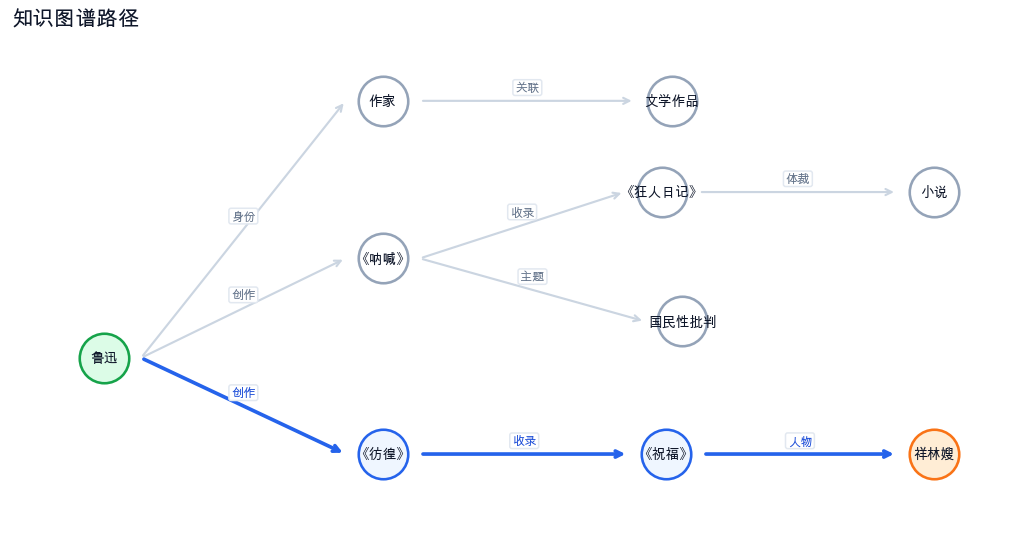

In [6]:
# 绘制最高分路径：突出多跳推理经过的实体和关系。
def draw_kg_path(triples, best_path):
    nodes = sorted(set([h for h, _, _ in triples] + [t for _, _, t in triples]))
    layout = {
        "鲁迅": (0.1, 1.2),
        "《呐喊》": (1.45, 1.8),
        "《彷徨》": (1.45, 0.62),
        "《狂人日记》": (2.8, 2.2),
        "国民性批判": (2.9, 1.42),
        "《祝福》": (2.82, 0.62),
        "祥林嫂": (4.12, 0.62),
        "作家": (1.45, 2.75),
        "文学作品": (2.85, 2.75),
        "小说": (4.12, 2.2),
    }
    active = {(edge["head"], edge["relation"], edge["tail"]) for edge in best_path}
    active_nodes = {edge["head"] for edge in best_path} | {edge["tail"] for edge in best_path}

    fig, ax = plt.subplots(figsize=(9.5, 5.0))
    ax.set_facecolor("#fbfcfd")
    for head, relation, tail in triples:
        x1, y1 = layout[head]
        x2, y2 = layout[tail]
        is_active = (head, relation, tail) in active
        ax.annotate(
            "",
            xy=(x2 - 0.18, y2),
            xytext=(x1 + 0.18, y1),
            arrowprops={
                "arrowstyle": "->",
                "color": "#2563eb" if is_active else "#cbd5e1",
                "lw": 2.4 if is_active else 1.4,
            },
            zorder=1,
        )
        ax.text(
            (x1 + x2) / 2,
            (y1 + y2) / 2 + 0.08,
            relation,
            ha="center",
            va="center",
            fontsize=8,
            color="#1d4ed8" if is_active else "#64748b",
            bbox={"boxstyle": "round,pad=0.18", "fc": "white", "ec": "#e2e8f0"},
            zorder=2,
        )

    for node in nodes:
        x, y = layout[node]
        is_active = node in active_nodes
        face = "#eff6ff" if is_active else "#ffffff"
        edge = "#2563eb" if is_active else "#94a3b8"
        if node == start_entity:
            face, edge = "#dcfce7", "#16a34a"
        if node == target_entity:
            face, edge = "#ffedd5", "#f97316"
        ax.scatter(x, y, s=1050, color=face, edgecolor=edge, linewidth=1.7, zorder=3)
        ax.text(x, y, node, ha="center", va="center", fontsize=9, fontweight="bold", color="#0f172a", zorder=4)

    ax.set_title("知识图谱路径", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
    ax.set_xlim(-0.35, 4.55)
    ax.set_ylim(0.18, 3.15)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


draw_kg_path(triples, paths[ranked_paths.index[0]])